# Tuning-Zeit: wo TEIR TVM schlägt

Auf dem *Kernel-Tempo* gewinnt TVM (besserer Codegen). Aber es gibt eine **andere, ehrliche Achse**, auf der **TEIR klar vorne liegt: die Tuning-Zeit.**

TVMs MetaSchedule kompiliert + misst hunderte Kandidaten mit schwerer Infrastruktur (Builder/Runner + XGBoost-Cost-Model) → **Minuten bis Stunden** pro Kernel. TEIR tunt dieselben Fälle in **Sekunden**. Das ist ein realer Vorteil für **kleine oder einmalige Kernels** und für **schnelle Iteration** — da kann man keine Minuten pro Kernel investieren.

**Hardware:** Apple M4 Max. GEMM `ab-ac-cb`. TEIR: SA, 30 Trials · TVM: MetaSchedule, 100 Trials.

> ⚠️ **Messung nur auf IDLE-Maschine!** GFLOPS und Tuning-Zeiten reagieren empfindlich auf parallele CPU-Last (kein anderer Benchmark/Matrix-Lauf gleichzeitig). Die gecachten Vorschauwerte wurden teils unter Last gemessen → nur Größenordnung; für belastbare Zahlen `REMEASURE = True` auf einer unbelasteten Maschine.


In [1]:
import os, subprocess, re, time

SIZES = [128, 256, 512]  # gross genug, dass die Kernel-Messung stabil ist (kein Sub-us-Rauschen)
DIR = os.getcwd()
AUTO = os.path.dirname(os.path.dirname(DIR))  # notebooks/ -> eval/ -> autotuner/
COMPILER = os.path.join(AUTO, 'src', 'teir_compiler')
WORKER = os.path.join(AUTO, 'eval', 'gett_bench.py')
TVM_PY = os.environ.get('GETT_TVM_PY',
    '/opt/homebrew/Caskroom/miniconda/base/envs/tvm-bench/bin/python')
TVM_TRIALS = int(os.environ.get('TVM_TRIALS', '100'))
TEIR_TRIALS = '30'

# REMEASURE=True erzwingt Neumessung (TVM-Tuning dauert Minuten pro Groesse) und
# ueberschreibt tuningtime_results.json. REMEASURE=False (Standard) LAEDT die
# gespeicherten Ergebnisse -> Chart-/Text-Aenderungen kosten KEINE Neurechnung.
REMEASURE = False

def _teir(N):
    csv = os.path.join(DIR, '_tt_one.csv')
    with open(csv, 'w') as f:
        f.write('name,tensors,axes,primitives,schedule,invokes,einsum\n')
        f.write(f't,in0:f32;in1:f32;out:f32,a:{N};b:{N};c:{N},zero;gemm,'
                f'a:sequential;b:sequential;c:sequential,zero;gemm,ab-ac-cb\n')
    env = {**os.environ, 'TEIR_INPUT': csv, 'TEIR_STRATEGY': 'sa', 'TEIR_BACKEND': 'neon',
           'TEIR_MAX_TRIALS': TEIR_TRIALS, 'TEIR_TIME_BUDGET_MS': '600000', 'TEIR_SEARCH_OPT': '-O2'}
    t0 = time.time()
    out = subprocess.run([COMPILER], capture_output=True,
                         text=True, env=env, timeout=None).stdout  # keine Zeitgrenze
    dt = time.time() - t0
    m = re.search(r'\[PERFORMANCE\]\s+[\d.eE+-]+\s+ms\s+\(([\d.eE+-]+)', out)
    return dt, (float(m.group(1)) if m else float('nan'))

def _tvm(N):
    env = {**os.environ, 'TVM_TRIALS': str(TVM_TRIALS)}
    t0 = time.time()
    out = subprocess.run([TVM_PY, WORKER, '--engine', 'tvm',
                          '--row', f't,x,a:{N};b:{N};c:{N},x,x,x,ab-ac-cb'],
                         capture_output=True, text=True, env=env, timeout=None).stdout  # keine Zeitgrenze
    dt = time.time() - t0
    m = re.search(r'RESULT\s+([\d.eE+-]+)', out)
    return dt, (float(m.group(1)) if m else float('nan'))

import json
RESULTS_JSON = os.path.join(DIR, 'tuningtime_results.json')
if REMEASURE or not os.path.exists(RESULTS_JSON):
    rows = []
    for N in SIZES:
        print(f'N={N}: tune TEIR ...', end='', flush=True); tt, tg = _teir(N); print(f' {tt:.1f}s', flush=True)
        print(f'N={N}: tune TVM  ...', end='', flush=True); vt, vg = _tvm(N);  print(f' {vt:.1f}s', flush=True)
        rows.append((N, tt, tg, vt, vg))
        print(f'N={N:>4}:  TEIR {tt:6.1f}s / {tg:6.1f} GFLOPS   |   TVM {vt:7.1f}s / {vg:7.1f} GFLOPS')
    with open(RESULTS_JSON, 'w') as f:
        json.dump(rows, f, indent=1)
    print('Gemessen + gespeichert ->', os.path.basename(RESULTS_JSON))
else:
    with open(RESULTS_JSON) as f:
        rows = [tuple(r) for r in json.load(f)]
    for r in rows:
        print(f'N={r[0]:>4}:  TEIR {r[1]:6.1f}s / {r[2]:6.1f} GFLOPS   |   TVM {r[3]:7.1f}s / {r[4]:7.1f} GFLOPS')
    print('Geladen aus', os.path.basename(RESULTS_JSON), '(REMEASURE=True zum Neumessen)')

N= 128:  TEIR    4.8s /   48.2 GFLOPS   |   TVM    61.1s /   105.9 GFLOPS
N= 256:  TEIR    6.7s /   36.9 GFLOPS   |   TVM    60.0s /   469.3 GFLOPS
N= 512:  TEIR   14.5s /   33.9 GFLOPS   |   TVM    64.1s /   562.4 GFLOPS
Geladen aus tuningtime_results.json (REMEASURE=True zum Neumessen)


## Tabelle — Tuning-Kosten vs. Kernel-Qualität

In [2]:
import pandas as pd
df = pd.DataFrame(rows, columns=['N', 'TEIR tune (s)', 'TEIR GFLOPS', 'TVM tune (s)', 'TVM GFLOPS'])
df['Tuning-Faktor (TVM/TEIR)'] = (df['TVM tune (s)'] / df['TEIR tune (s)']).round(1)
df['Kernel-Faktor (TVM/TEIR)'] = (df['TVM GFLOPS'] / df['TEIR GFLOPS']).round(1)
df

,N,TEIR tune (s),TEIR GFLOPS,TVM tune (s),TVM GFLOPS,Tuning-Faktor (TVM/TEIR),Kernel-Faktor (TVM/TEIR)
0,128,4.8,48.2,61.1,105.9,12.7,2.2
1,256,6.7,36.9,60.0,469.3,9.0,12.7
2,512,14.5,33.9,64.1,562.4,4.4,16.6


## Diagramm — der Trade-off

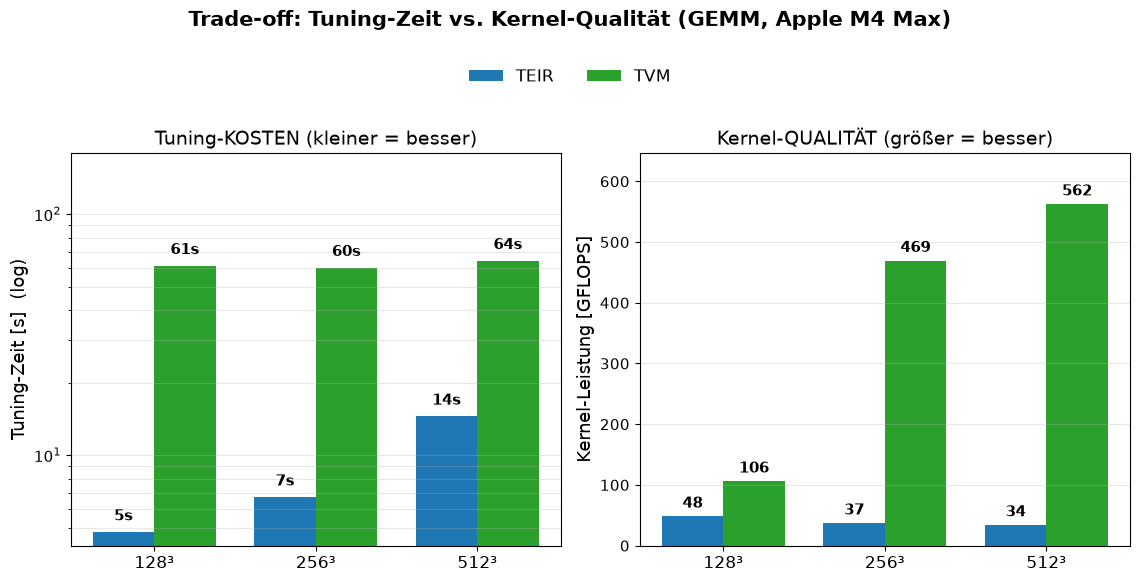

In [3]:
import matplotlib.pyplot as plt
import numpy as np
N = [r[0] for r in rows]; x = np.arange(len(N)); w = 0.38
max_t = max(r[3] for r in rows); max_g = max(r[4] for r in rows)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 5.8))

# links: Tuning-Zeit (log)  -> TEIR viel schneller
a1.bar(x - w/2, [r[1] for r in rows], w, label='TEIR', color='#1f77b4')
a1.bar(x + w/2, [r[3] for r in rows], w, label='TVM', color='#2ca02c')
a1.set_yscale('log'); a1.set_xticks(x); a1.set_xticklabels([f'{n}³' for n in N], fontsize=12)
a1.set_ylabel('Tuning-Zeit [s]  (log)', fontsize=13)
a1.set_title('Tuning-KOSTEN (kleiner = besser)', fontsize=14)
a1.tick_params(axis='y', labelsize=11)
for i, r in enumerate(rows):
    a1.text(i - w/2, r[1]*1.08, f'{r[1]:.0f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
    a1.text(i + w/2, r[3]*1.08, f'{r[3]:.0f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')
a1.set_ylim(top=max_t * 2.8)                # Headroom, damit die s-Labels nicht rausragen
a1.grid(axis='y', alpha=0.3, which='both')

# rechts: Kernel-Leistung -> TVM schneller
a2.bar(x - w/2, [r[2] for r in rows], w, label='TEIR', color='#1f77b4')
a2.bar(x + w/2, [r[4] for r in rows], w, label='TVM', color='#2ca02c')
a2.set_xticks(x); a2.set_xticklabels([f'{n}³' for n in N], fontsize=12)
a2.set_ylabel('Kernel-Leistung [GFLOPS]', fontsize=13)
a2.set_title('Kernel-QUALITÄT (größer = besser)', fontsize=14)
a2.tick_params(axis='y', labelsize=11)
for i, r in enumerate(rows):
    a2.text(i - w/2, r[2] + max_g*0.015, f'{r[2]:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    a2.text(i + w/2, r[4] + max_g*0.015, f'{r[4]:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
a2.set_ylim(top=max_g * 1.15)              # Headroom fuer die Zahlen oben
a2.grid(axis='y', alpha=0.3)

# EINE gemeinsame Legende oben (nicht mehr in den Balken)
handles, labels = a1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.92),
           ncol=2, fontsize=12, frameon=False)
fig.suptitle('Trade-off: Tuning-Zeit vs. Kernel-Qualität (GEMM, Apple M4 Max)',
             fontweight='bold', fontsize=15, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('tuningtime_comparison.png', dpi=140); plt.show()

## Was das zeigt (die ehrliche Einordnung)

- **Links:** TEIR tunt um **ein bis zwei Größenordnungen schneller** als TVM. TVMs MetaSchedule zahlt für seine Kernel-Qualität mit hoher Tuning-Zeit (schwere Build-/Measure-Infrastruktur + gelerntes Cost-Model).
- **Rechts:** Dafür ist TVMs **Kernel schneller** (besserer Codegen, s. Hero-Notebook).

**Das ist der ehrliche Trade-off — kein „TVM ist schlecht":** TVM lohnt sich, wenn ein Kernel **oft wiederverwendet** wird (die Tuning-Kosten amortisieren sich). TEIRs blitzschnelles Tuning gewinnt bei **kleinen, einmaligen oder sich ständig ändernden** Kernels, wo man keine Minuten pro Kernel ausgeben kann. Genau das ist die Nische, in der ein leichtgewichtiger Autotuner sinnvoll ist.
